# File processing

In [2]:
## Importing 'packages'
import pandas as pd
import numpy as np
import os
import thebeat
import matplotlib.pyplot as plt
import seaborn as sns

TRIAL_CONDITIONS = [50, 150, 0, 100, 200]
STIMULUS_INTERVAL = 0.5
N_INTERVALS = 24
STIMULUS_ONSETS = np.cumsum([0] + [STIMULUS_INTERVAL] * N_INTERVALS)[:-1]

In [ ]:
onsets = pd.DataFrame()

filenames = [file for file in os.listdir('./data') if file.endswith('.csv')]

for file in filenames:
    df_response = pd.read_csv(os.path.join('./data', file))
    pp_id = df_response.participant[0]
    for i, trial in enumerate(TRIAL_CONDITIONS):
        stimulus_onset_time = df_response[f"stimulus.started"].dropna().values[0]
        response_onsets_time = df_response[f"resp.time"].dropna().values
        response_onsets = response_onsets_time - stimulus_onset_time
        response_velocity = df_response[f"resp.velocity.{i+1}"].dropna().values

        for stim_resp in ['stimulus', 'response']:
            onsets = pd.concat([onsets, pd.DataFrame({
                'pp_id': pp_id,
                'trial_condition': trial,
                'stimulus_response': stim_resp,
                'onset_i': np.arange(len(response_onsets)) if stim_resp == 'response' else np.arange(len(STIMULUS_ONSETS)),
                'onset': response_onsets if stim_resp == 'response' else STIMULUS_ONSETS,
                'velocity': response_velocity if stim_resp == 'response' else np.nan
            })])

onsets.to_csv(os.path.join("data", "processed", "onsets.csv"), index=False)

iois = pd.DataFrame()

for file in filenames:
    df_response = pd.read_csv(os.path.join('./data', file))
    pp_id = df_response.participant[0]
    for i, trial in enumerate(TRIAL_CONDITIONS):
        stimulus_onset_time = df_response[f"stimulus_{trial}.started"].dropna().values[0]
        response_onsets_time = df_response[f"resp.time.{i+1}"].dropna().values
        response_onsets = response_onsets_time - stimulus_onset_time

        iois = pd.concat([iois, pd.DataFrame({
            'pp_id': pp_id,
            'trial_condition': trial,
            'ioi_i': np.arange(len(response_onsets) - 1),
            'ioi': np.diff(response_onsets)
        })])

iois.to_csv(os.path.join("data", "processed", "iois.csv"), index=False)

KeyError: 'resp.time'

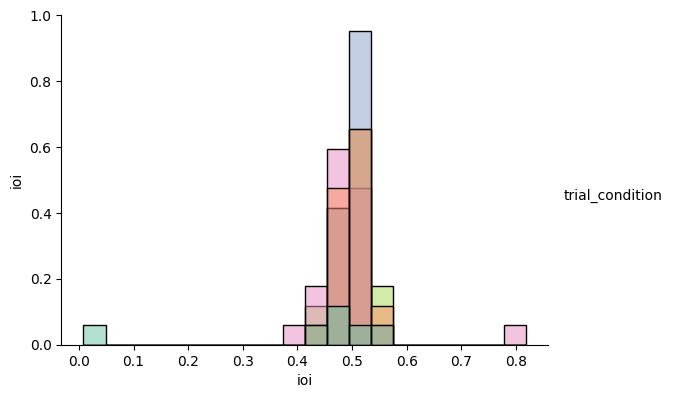

In [59]:
p = sns.pairplot(iois, hue="trial_condition", vars=["ioi"], height=4, aspect=11.7/8.27, palette="Set2", diag_kind="hist")